<a href="https://colab.research.google.com/github/satyamkarn100-ctrl/CyberShield-Threat-Detector/blob/main/URL-Phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

!pip install -q xgboost lightgbm imbalanced-learn tldextract

import tldextract
import re
import os
import random
import zipfile
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
import lightgbm as lgb


# Kaggle setup
os.environ['KAGGLE_API_TOKEN'] = 'Enter your API'

!pip install -q kaggle

# Download dataset
!kaggle datasets download -d sid321axn/malicious-urls-dataset


# Unzip dataset
with zipfile.ZipFile('/content/malicious-urls-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving url_dataset.csv to url_dataset (1).csv


##  Load Dataset

Raw file has 2 columns — `url` and `type`. Keeping original df clean before adding anything to it.

In [ ]:
malicious_df = pd.read_csv(r'malicious_phish.csv')
historic_df = malicious_df.copy()
malicious_df.head(10)

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign
8,http://www.pashminaonline.com/pure-pashminas,defacement
9,allmusic.com/album/crazy-from-the-heat-r16990,benign


### Insight

> Initial real-world testing showed that the original Kaggle dataset was not diverse enough for legitimate URL patterns. I added a small manual dataset with realistic benign URLs to improve the model's exposure to real-world examples before retraining.

In [ ]:
# Added a small manual dataset because the model was overpredicting phishing
# on some real-world URLs from the original Kaggle dataset. These samples
# helped improve its behavior on such URL patterns.
manual_df = pd.read_csv(r'url_dataset.csv')
manual_df.head(10)

,url,type
0,https://google.com,benign
1,https://microsoft.com,benign
2,https://amazon.com,benign
3,https://apple.com,benign
4,https://youtube.com,benign
5,https://wikipedia.org,benign
6,https://linkedin.com,benign
7,https://instagram.com,benign
8,https://facebook.com,benign
9,https://netflix.com,benign


## Data Inspection

Checking class distribution, data quality, and duplicates before touching anything. Dataset is heavily imbalanced — benign is 66% of all rows. 10k+ duplicates expected in a real-world scraped URL dataset.

In [ ]:
# Initial sanity check: Inspecting class imbalance and data quality before feature engineering
print(f"Shape: {malicious_df.shape}")
print("\nLabel distribution:")
print(malicious_df['type'].value_counts())
print('\nMissing Values:')
print(malicious_df.isnull().sum())
print(f"\nDuplicates: {malicious_df.duplicated().sum()}")

Shape: (651191, 2)

Label distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Missing Values:
url     0
type    0
dtype: int64

Duplicates: 10066


In [ ]:
# Dropping exact repeated URLs to prevent model bias and avoid data leakage between train/test sets
malicious_df.drop_duplicates(inplace=True)
malicious_df = malicious_df.reset_index(drop=True)
print(f'After cleaning duplicates: {malicious_df.shape}')


After dedup+reset: (641125, 2)


In [ ]:
print('Duplicate:',malicious_df.duplicated().sum())

Duplicate: 0


In [ ]:
# Merge original and manually added data, then check for exact duplicates
df = pd.concat([malicious_df, manual_df], ignore_index=True)

print("After Merge:", df.shape, '\n\n')
print("Exact duplicate rows:", df.duplicated().sum())

After Merge: (641173, 2) 


Excat duplicate rows: 1


### Insight

> The datasets were merged and exact duplicate rows were checked before training so repeated URLs would not unnecessarily influence the model.

In [ ]:
df[df.duplicated(keep=False)]

,url,type
641168,https://drive.google.com/uc?export=download&id...,malware
641169,https://drive.google.com/uc?export=download&id...,malware


In [ ]:
# Remove duplicates and reset the index
df = df.drop_duplicates().reset_index(drop=True)
print("Rechecking Duplicate:",df.duplicated().sum())

Rechecking Duplicate: 0


> Duplicate URLs were removed to keep the training data clean and reduce repeated examples.

In [91]:
print("After Merging manual and malicious_df")
print(f"Shape: {df.shape}")
print("\nLabel distribution:")
print(df['type'].value_counts())
print('\nMissing Values:')
print(df.isnull().sum())
print(f"\nDuplicates: {df.duplicated().sum()}")

After Merging manual and malicious_df
Shape: (641172, 16)

Label distribution:
type
benign        428098
defacement     95308
phishing       94106
malware        23660
Name: count, dtype: int64

Missing Values:
url                   0
type                  0
label                 0
url_length            0
hyphen_count          0
dot_count             0
slash_count           0
special_char_count    0
has_at                0
has_double_slash      0
subdomain_count       0
query_length          0
path_length           0
phishing_keyword      0
has_ip                0
tld                   0
dtype: int64

Duplicates: 0


In [92]:
df.head()

,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip,tld
0,http://br-icloud.com.br,phishing,1,16,1,2,0,0,0,0,1,0,0,0,0,com.br
1,http://mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,0,0,0,0,23,0,0,com
2,http://bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,0,0,0,0,16,0,0,org
3,http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15,defacement,2,81,1,3,1,8,0,0,1,49,9,0,0,be
4,http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlkPTU0,defacement,2,228,1,2,1,6,0,0,0,194,9,0,0,net


In [ ]:
# Normalize URLs to a consistent format
def normalize_url(url):
    url = str(url).strip()
    if not re.match(r'^https?://', url, re.IGNORECASE):
        url = 'http://' + url
    return url

df['url'] = df['url'].apply(normalize_url)
print('Normalized. Sample:')
print(df['url'].head(5).tolist())


Normalized. Sample:
['http://br-icloud.com.br', 'http://mp3raid.com/music/krizz_kaliko.html', 'http://bopsecrets.org/rexroth/cr/1.htm', 'http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15', 'http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlkPTU0']


> URLs were standardized into a consistent format before feature extraction, so the same URL structure is processed consistently by the model.

## Label Encoding

Manual mapping instead of sklearn's LabelEncoder — this way we control which number maps to which class. Matters when reading the confusion matrix later.

In [ ]:
# Converting text classes to numeric targets since ML algorithms (like XGBoost) can't process strings
label_map = {
    'benign': 0,
    'phishing':1,
    'defacement':2,
    'malware':3,
}
df['label'] = df['type'].map(label_map)
# Double-checking the mapping and ensuring no unmapped garbage values slipped through
print(df[['type','label']].drop_duplicates().sort_values('label'))
print(f"\nNull Labels:{df['label'].isnull().sum()}")

df = df.reset_index(drop=True)
print(f'After dedup+reset: {df.shape}')


          type  label
1       benign      0
0     phishing      1
3   defacement      2
38     malware      3

Null Labels:0
After dedup+reset: (641172, 3)


### Feature Engineering
This is the NLP part — treating the raw URL string as text and extracting signals from it. I've grouped the extracted features into 4 main categories:

* **Statistical:** `url_length`, `hyphen_count`, `dot_count`, `slash_count`, `special_char_count`
  *(Catches unusually long or complex structures)*
* **Structural:**  `has_at`, `has_double_slash`
  *(Catches protocol tricks and redirect abuse)*
* **Domain/Path:** `subdomain_count`, `query_length`, `path_length`
  *(Catches deep hiding subdomains and suspiciously long parameters)*
* **Semantic:** `phishing_keyword`, `has_ip`
  *(Catches social engineering words and raw IP-based routing)*

In [ ]:
# Extract URL features for model training
def extract_feature(url):
    url = str(url)
    # strip protocol before feature extraction
    url_clean = re.sub(r'^https?://', '', url, flags=re.IGNORECASE)
    f = {}
    f['url_length']         = len(url_clean)
    f['hyphen_count']       = url_clean.count('-')
    f['dot_count']          = url_clean.count('.')
    f['slash_count']        = url_clean.count('/')
    f['special_char_count'] = len(re.findall(r'[@?=&%]', url_clean))
    f['has_at']             = int('@' in url_clean)
    f['has_double_slash']   = int('//' in url_clean)
    domain_only             = url_clean.split('/')[0]
    f['subdomain_count']    = max(domain_only.count('.') - 1, 0)
    if '?' in url_clean:
        bq, aq              = url_clean.split('?', 1)
        f['query_length']   = len(aq)
        f['path_length']    = len(bq.split('/', 1)[1]) if '/' in bq else 0
    else:
        f['query_length']   = 0
        f['path_length']    = len(url_clean.split('/', 1)[1]) if '/' in url_clean else 0
    kw = r'login|verify|secure|bank|paypal|update|account|signin'
    f['phishing_keyword']   = int(bool(re.search(kw, url_clean, re.IGNORECASE)))
    ip_pat = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'
    f['has_ip']             = int(bool(re.search(ip_pat, url_clean)))
    return f

feature_list = df['url'].apply(extract_feature).tolist()
features_df  = pd.DataFrame(feature_list)

# Add extracted features back to the dataset
FEAT_COLS = list(features_df.columns)
for col in FEAT_COLS:
    df[col] = features_df[col].values

print(f'features_df shape: {features_df.shape}')
print(f'malicious_df columns: {list(df.columns)}')
print(features_df.head())

features_df shape: (641172, 12)
malicious_df columns: ['url', 'type', 'label', 'url_length', 'hyphen_count', 'dot_count', 'slash_count', 'special_char_count', 'has_at', 'has_double_slash', 'subdomain_count', 'query_length', 'path_length', 'phishing_keyword', 'has_ip']
   url_length  hyphen_count  dot_count  slash_count  special_char_count  \
0          16             1          2            0                   0   
1          35             0          2            2                   0   
2          31             0          2            3                   0   
3          81             1          3            1                   8   
4         228             1          2            1                   6   

   has_at  has_double_slash  subdomain_count  query_length  path_length  \
0       0                 0                1             0            0   
1       0                 0                0             0           23   
2       0                 0                0           

>Each URL was converted into structural features such as length, dots, slashes, subdomains, query length, phishing keywords, and IP presence. These features provide the model with measurable patterns for classification

In [ ]:
# Quick sanity check for URL feature extraction
test_urls = [
    'https://google.com',
    'https://paypal-verify.xyz/login',
    'http://site.com//redirect/evil',
    'http://192.168.1.1/payload'
]

for u in test_urls:
    f = extract_feature(u)
    print(f'URL: {u}')
    print(f'  slash={f["slash_count"]}  double_slash={f["has_double_slash"]}  ip={f["has_ip"]}  keyword={f["phishing_keyword"]}')

URL: https://google.com
  slash=0  double_slash=0  ip=0  keyword=0
URL: https://paypal-verify.xyz/login
  slash=1  double_slash=0  ip=0  keyword=1
URL: http://site.com//redirect/evil
  slash=3  double_slash=1  ip=0  keyword=0
URL: http://192.168.1.1/payload
  slash=1  double_slash=0  ip=1  keyword=0


The custom test cases confirm that the extraction logic is detecting the expected signals, including phishing keywords, repeated slashes, and IP-based URLs

In [ ]:
# Define the features used by the model
feature_cols = [
    'url_length', 'hyphen_count', 'dot_count', 'slash_count',
    'special_char_count', 'has_at', 'has_double_slash',
    'subdomain_count', 'query_length', 'path_length',
    'phishing_keyword', 'has_ip'
]

print('Feature columns:', feature_cols)

feature_cols: ['url_length', 'hyphen_count', 'dot_count', 'slash_count', 'special_char_count', 'has_at', 'has_double_slash', 'subdomain_count', 'query_length', 'path_length', 'phishing_keyword', 'has_ip']


>The final feature set focuses on URL structure and commonly observed suspicious signals rather than relying on the raw URL text alone

In [ ]:
df.head()

,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip
0,http://br-icloud.com.br,phishing,1,16,1,2,0,0,0,0,1,0,0,0,0
1,http://mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,0,0,0,0,23,0,0
2,http://bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,0,0,0,0,16,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,2,81,1,3,1,8,0,0,1,49,9,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,2,228,1,2,1,6,0,0,0,194,9,0,0


###Exploratory Data Analysis (EDA)

*Note: Doing EDA after Feature Engineering is an intentional choice here.*

Raw URL strings don't give us much to plot or analyze directly. By extracting our numerical features first, we can now actually visualize things like URL length distributions, structural tricks, and hidden patterns across different classes. Let's see what the data tells us!

### Class Distribution & The Real-World Catch

* **Initial thought:** "66% benign — imbalanced but not extreme. `class_weight='balanced'` in the model will handle it."
* **The Reality:** Testing proved this assumption wrong. While `class_weight` fixes the *numerical* imbalance, it cannot fix *dataset bias*.
* **The Issue:** The 66% benign URLs in this Kaggle dataset lack representation of short, bare domains (like `google.com`). Forcing the model to prioritize the minority classes just made it over-sensitive, leading to false positives on unseen safe domains.

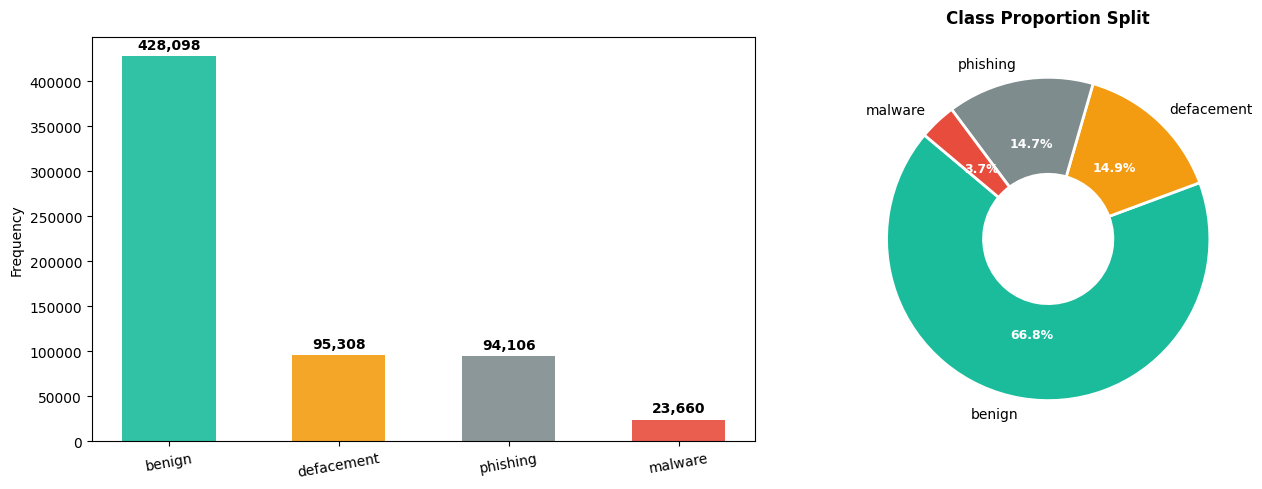

In [ ]:
# Visualizing the target distribution to highlight the severe class imbalance.
# The bar chart shows absolute volume, while the donut chart exposes the percentage skew (justifying why we care more about F1/Recall than pure Accuracy)
fig,axes = plt.subplots(1,2,figsize=(14,5))
counts = df['type'].value_counts()
bar_colors = ['#1abc9c', '#f39c12', '#7f8c8d', '#e74c3c']
bars = axes[0].bar(counts.index,counts.values,color=bar_colors,edgecolor="none",width=0.55,alpha=0.9)
axes[0].set_ylabel('Frequency',fontsize=10)
axes[0].tick_params(axis='x', rotation=10)

for i in bars:
  yval = i.get_height()
  axes[0].text(i.get_x()+ i.get_width()/2.0,yval+5000,f"{yval:,}",
               ha='center',va = 'bottom',fontsize=10,fontweight='bold')


wadges,texts,autotexts = axes[1].pie(counts.values,labels=counts.index
                                     ,autopct="%1.1f%%",startangle=140,colors = bar_colors,wedgeprops=dict(width=0.6,edgecolor='white',linewidth=2)
                                     )


plt.setp(autotexts, size=9, weight="bold", color="white")
plt.setp(texts, size=10)
axes[1].set_title('Class Proportion Split', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

##What this tells us:
>Benign = 66.8% (428,098 URLs), making it the majority class. This means accuracy alone can be misleading because a model could achieve a relatively high score by favoring the majority class.  
Defacement = 14.9% and phishing = 14.7% are fairly similar in size, while malware = 3.7% is the rarest class. Because malware samples are limited but security-wise important, its recall deserves particular attention.  
Bottom line: Class-wise precision, recall and Macro F1 give a more reliable picture of performance than accuracy alone, especially with this class imbalance

['http://77.228.191.183:7674/zeujuus/a/modules/config.bin', 'http://159.8.95.53/Financeiro/2Via(Boleto-Cobranca).zip', 'http://77.228.191.183:7890/zejius/5GPR0iy9/bot.exe', 'http://210.37.11.238/jm32/includes/site/gate.php', 'http://54.167.101.139/gg2.dat?a=5B0B283F-8345-2E4D-66FB-B4889E225B54&amp;b=13&amp;a=015&amp;b=15&amp;c=015_20150419_0731', 'http://61.132.88.42/zxyey/uploadfile/jpg/2010-10/20101015134043714.jpg', 'http://77.228.191.183:7890/zejius/2HZG41Zw/fJsnC6G4sFg2wsyn4shb.bin', 'http://210.37.11.238/jm32/includes/site/bot.exe', 'http://77.228.191.183:7890/zejius/5GPR0iy9/6Vtmo6w4yQ5tnsBHms64.php', 'http://77.228.191.183:7890/zejius/2HZG41Zw/6Vtmo6w4yQ5tnsBHms64.php', 'http://77.228.191.183:7890/zejius/2HZG41Zw/bot.exe', 'http://77.228.191.183:7674/zeujuus/a/gate.php', 'http://77.228.191.183:7674/zeujuus/a/modules/bot.exe', 'http://77.228.191.183:7890/zejius/5GPR0iy9/fJsnC6G4sFg2wsyn4shb.bin', 'http://210.37.11.238/jm32/includes/site/config.bin', 'http://95.8.55.230:23693/.i'

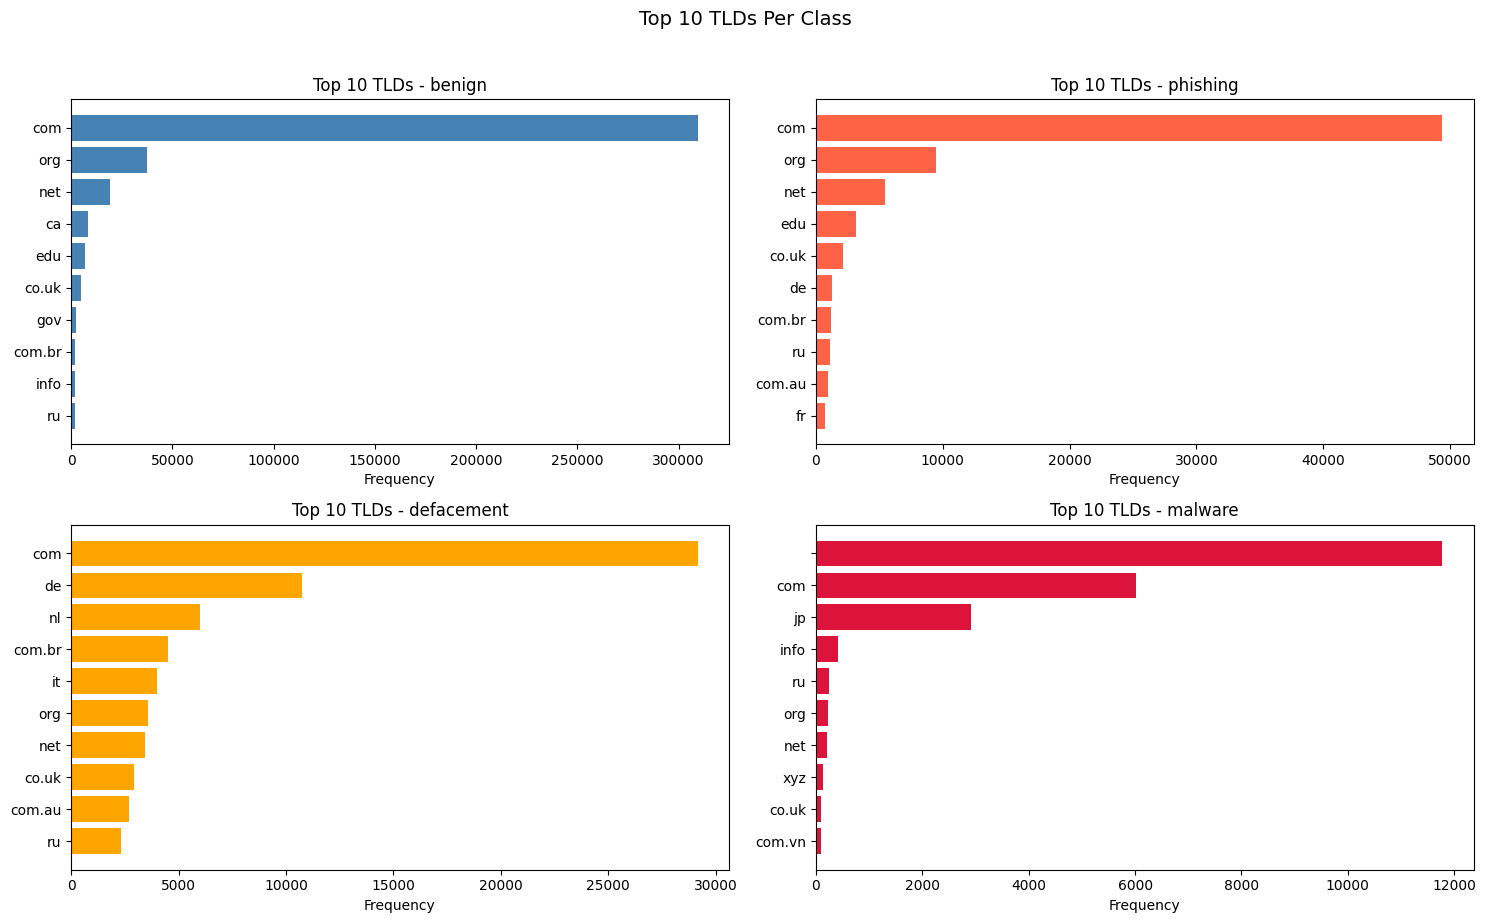

In [ ]:
df['tld'] = df['url'].apply(lambda x: tldextract.extract(str(x)).suffix)

malware_blanks = df[(df['type'] == 'malware') & ((df['tld'].isna()) | (df['tld'] == ''))]
print(malware_blanks['url'].head(20).tolist())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
colors = {'benign': 'steelblue', 'phishing': 'tomato', 'defacement': 'orange', 'malware': 'crimson'}

for ax, label in zip(axes.flatten(), ['benign', 'phishing', 'defacement', 'malware']):
    top_tld = df[df['type'] == label]['tld'].value_counts().head(10)
    ax.barh(top_tld.index[::-1], top_tld.values[::-1], color=colors[label])
    ax.set_title(f"Top 10 TLDs - {label}")
    ax.set_xlabel('Frequency')
plt.suptitle('Top 10 TLDs Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Convert blank or null TLDs into IP_Addressdf['tld'] = df['tld'].replace('', "IP_Address")
df['tld'] = df['tld'].fillna('IP_Address')

print(df['tld'].value_counts().head(10))

tld
com       393930
org        50771
net        28074
de         13472
           12223
edu        10077
co.uk      10007
ca          9449
com.br      7629
nl          7067
Name: count, dtype: int64


tld
com           393930
org            50771
net            28074
de             13472
IP_Address     12223
Name: count, dtype: int64


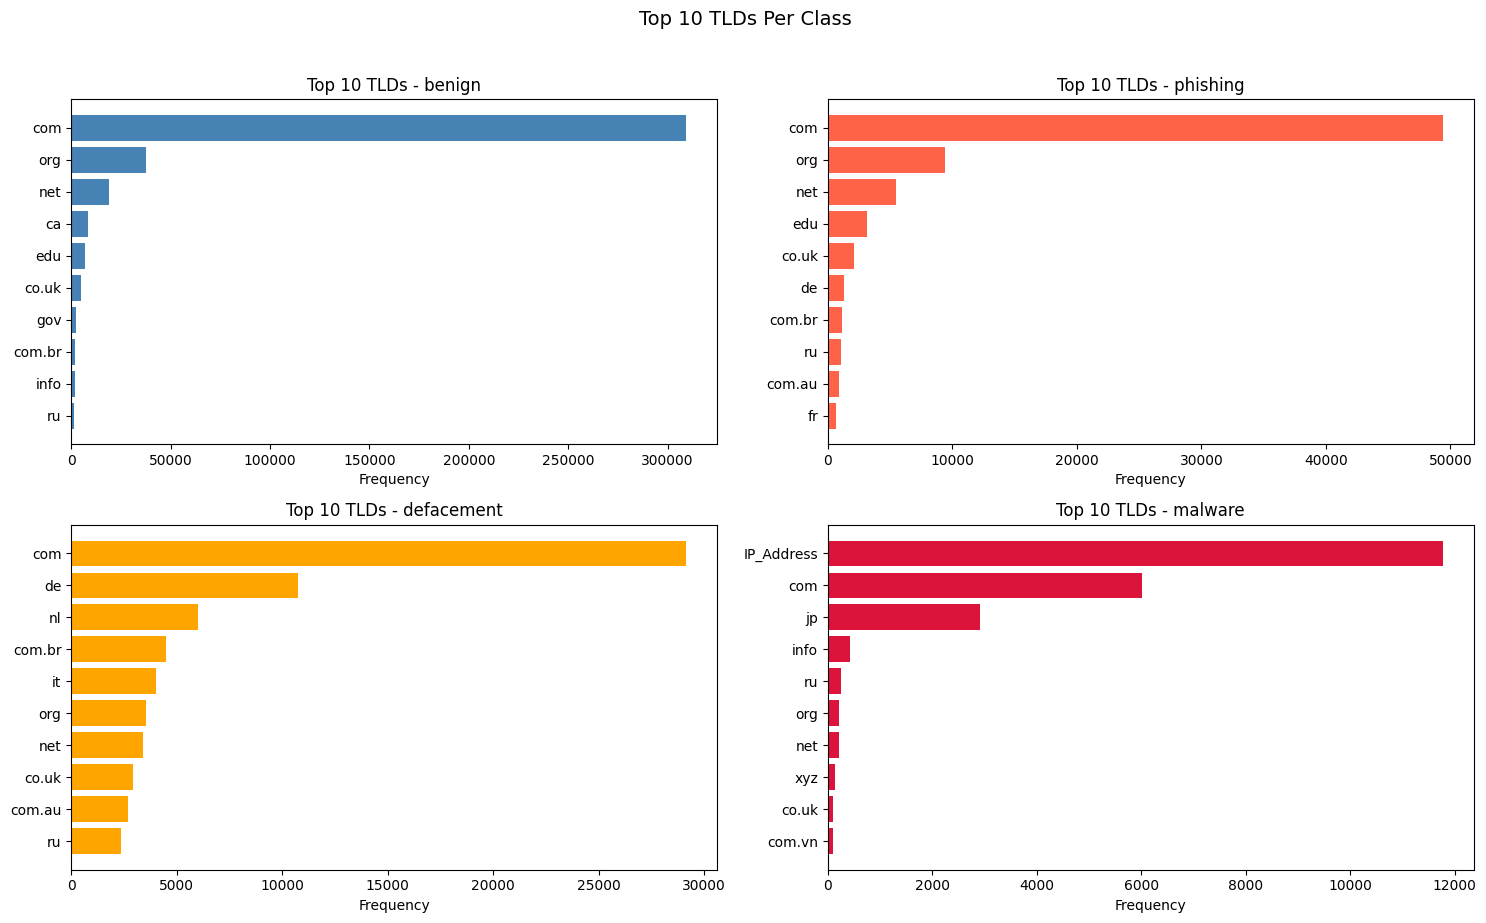

In [ ]:
# Standardizing missing TLDs: URLs without a domain extension are typically direct IP addresses.
# Explicitly grouping them as 'IP_Address' creates a powerful signal for the model to detect evasive malware
df['tld'] = df['tld'].astype(str).str.strip()
df.loc[df['tld'] == '', 'tld'] = 'IP_Address'
df.loc[df['tld'] == 'nan', 'tld'] = 'IP_Address'
print(df['tld'].value_counts().head(5))

# Visualizing the cleaned TLD distribution to verify how heavily 'IP_Address' dominates the malicious classes
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, label in zip(axes.flatten(), ['benign', 'phishing', 'defacement', 'malware']):
    top_tld = df[df['type'] == label]['tld'].value_counts().head(10)
    ax.barh(top_tld.index[::-1], top_tld.values[::-1], color=colors[label])
    ax.set_title(f"Top 10 TLDs - {label}")
    ax.set_xlabel('Frequency')
plt.suptitle('Top 10 TLDs Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### TLD Distribution Insights

Benign & Phishing: .com is by far the most common TLD in both classes, followed by .org and .net. This shows that phishing URLs can use the same common TLDs seen in legitimate websites, so TLD alone is not enough to distinguish them.
Defacement: The defacement class shows a more varied TLD distribution, with .com, .de, .nl, .com.br, and .it among the most frequent. This suggests that defacement examples in the dataset come from a diverse range of domains and country-level TLDs.
Malware: IP_Address is the most frequent entry in the malware class, followed by .com and .jp. This indicates that direct IP-based URLs are an important pattern in the malware samples and can provide a useful signal for the classifier.
Overall: The distribution shows why relying on a single TLD would be weak for URL classification. The model needs to combine TLD information with other URL characteristics such as URL structure, keywords, path length, and IP presence

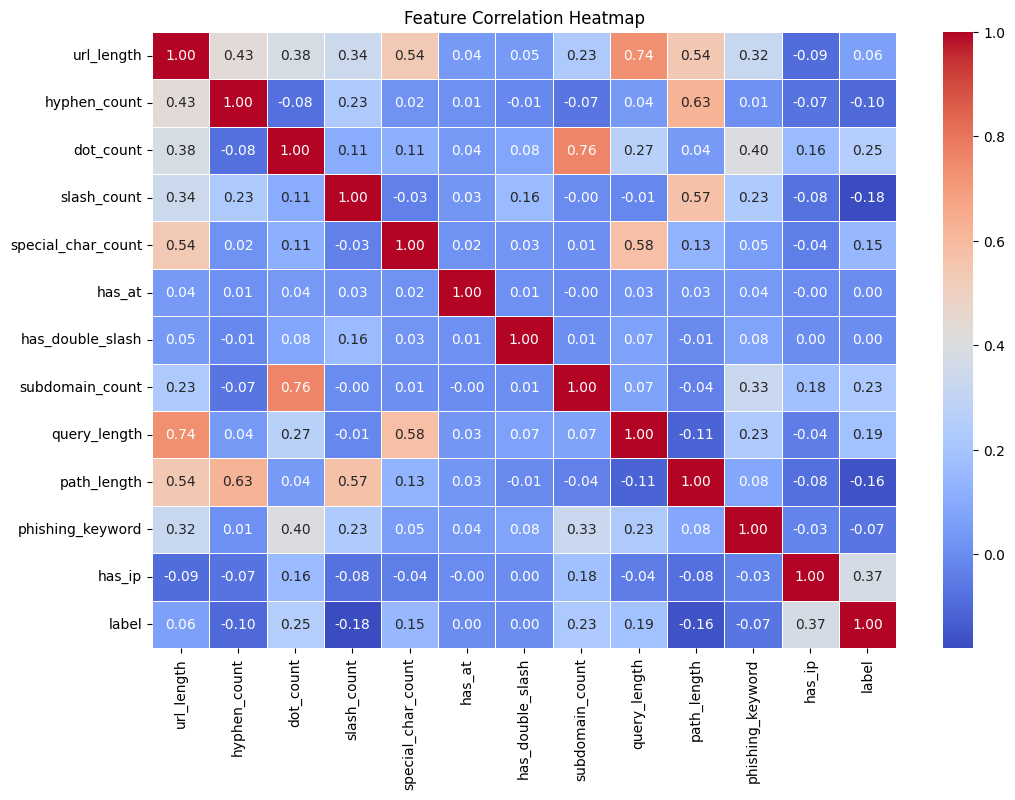

In [ ]:
# Add the label column to features_df just for this correlation plot
features_df['label'] = df['label']

# Now plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    features_df[feature_cols + ['label']].corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

###Correlation

>The heatmap shows a few strong relationships between URL-structure features. url_length and query_length have a correlation of 0.74, while dot_count and subdomain_count show 0.76, indicating that these feature pairs capture some overlapping information.
slash_count and path_length also show a moderate correlation (0.57). These relationships are useful for understanding feature redundancy, but correlation alone does not mean that one feature should be removed.

>The highest numerical correlation with the encoded label is has_ip (0.37), suggesting a noticeable relationship in this dataset. However, actual feature importance should be evaluated separately before deciding which features contribute most to the mode


### URL Length Distribution
Malware and defacement URLs tend to be longer — more path segments, longer query strings. Phishing is surprisingly short — quick redirect links.

/tmp/ipykernel_4843/1848158061.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],


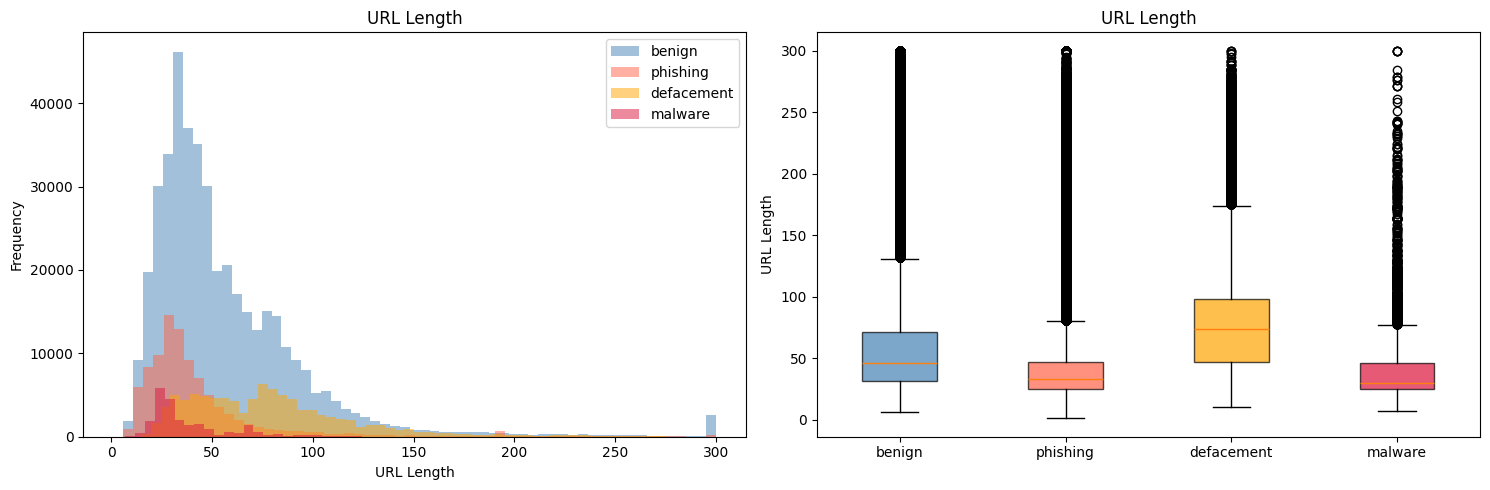

          count  mean   std   min   25%   50%   75%     max
label                                                      
0      428098.0  57.1  43.6   6.0  31.0  46.0  71.0  2175.0
1       94106.0  43.9  42.2   1.0  25.0  33.0  47.0  1771.0
2       95308.0  79.1  41.9  10.0  47.0  74.0  98.0   320.0
3       23660.0  39.7  24.6   7.0  25.0  30.0  46.0   371.0


In [ ]:
# Investigating if URL length is a strong differentiator. Malicious URLs are often unusually long to hide payloads or excessive parameters.
# Note: Clipping lengths at 300 characters strictly for visualization to prevent extreme outliers from squashing the charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = {0: 'steelblue', 1: 'tomato', 2: 'orange', 3: 'crimson'}

for name, lbl in label_map.items():
    data = df[df['label'] == lbl]['url_length'].clip(upper=300)
    axes[0].hist(data, bins=60, alpha=0.5, color=colors[lbl], label=name)

axes[0].set_xlabel("URL Length")
axes[0].set_ylabel('Frequency')
axes[0].set_title("URL Length")
axes[0].legend()

# Using a Boxplot to clearly see the medians and the spread of outliers across classes
box_data = [
    df[df['label'] == l]['url_length'].clip(upper=300).values
    for l in label_map.values()
]
bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],
                     patch_artist=True)

for box, color in zip(bp['boxes'], colors.values()):
    box.set_facecolor(color)
    box.set_alpha(0.7)

axes[1].set_title('URL Length')
axes[1].set_ylabel('URL Length')

plt.tight_layout()
plt.show()

# Printing exact summary statistics to back up our visual findings mathematically
print(df.groupby('label')['url_length'].describe().round(1))

###URL Length Distribution

>URL length varies noticeably across the four classes. Phishing and malware have relatively short median URL lengths (33 and 30 characters), while defacement has the highest median at 74 characters. Benign URLs fall between them with a median of 46 characters.

>The distributions also contain many long outliers, especially for benign, phishing, and malware URLs. This shows that URL length alone is not a reliable indicator of whether a URL is malicious, so the model needs to combine it with other structural features.

>One useful observation is that phishing does not necessarily mean a long URL. In this dataset, phishing URLs actually have a shorter median length than benign and defacement URLs, which makes it important to avoid simplistic rules such as “long URL = phishing.”

### Numerical Feature Distribution Per Class
Boxplots only for continuous numerical features — binary flags are handled separately below. Features with clearly different medians across classes are the most useful for the model.

/tmp/ipykernel_4843/2239296015.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_4843/2239296015.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_4843/2239296015.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_4843/2239296015.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matp

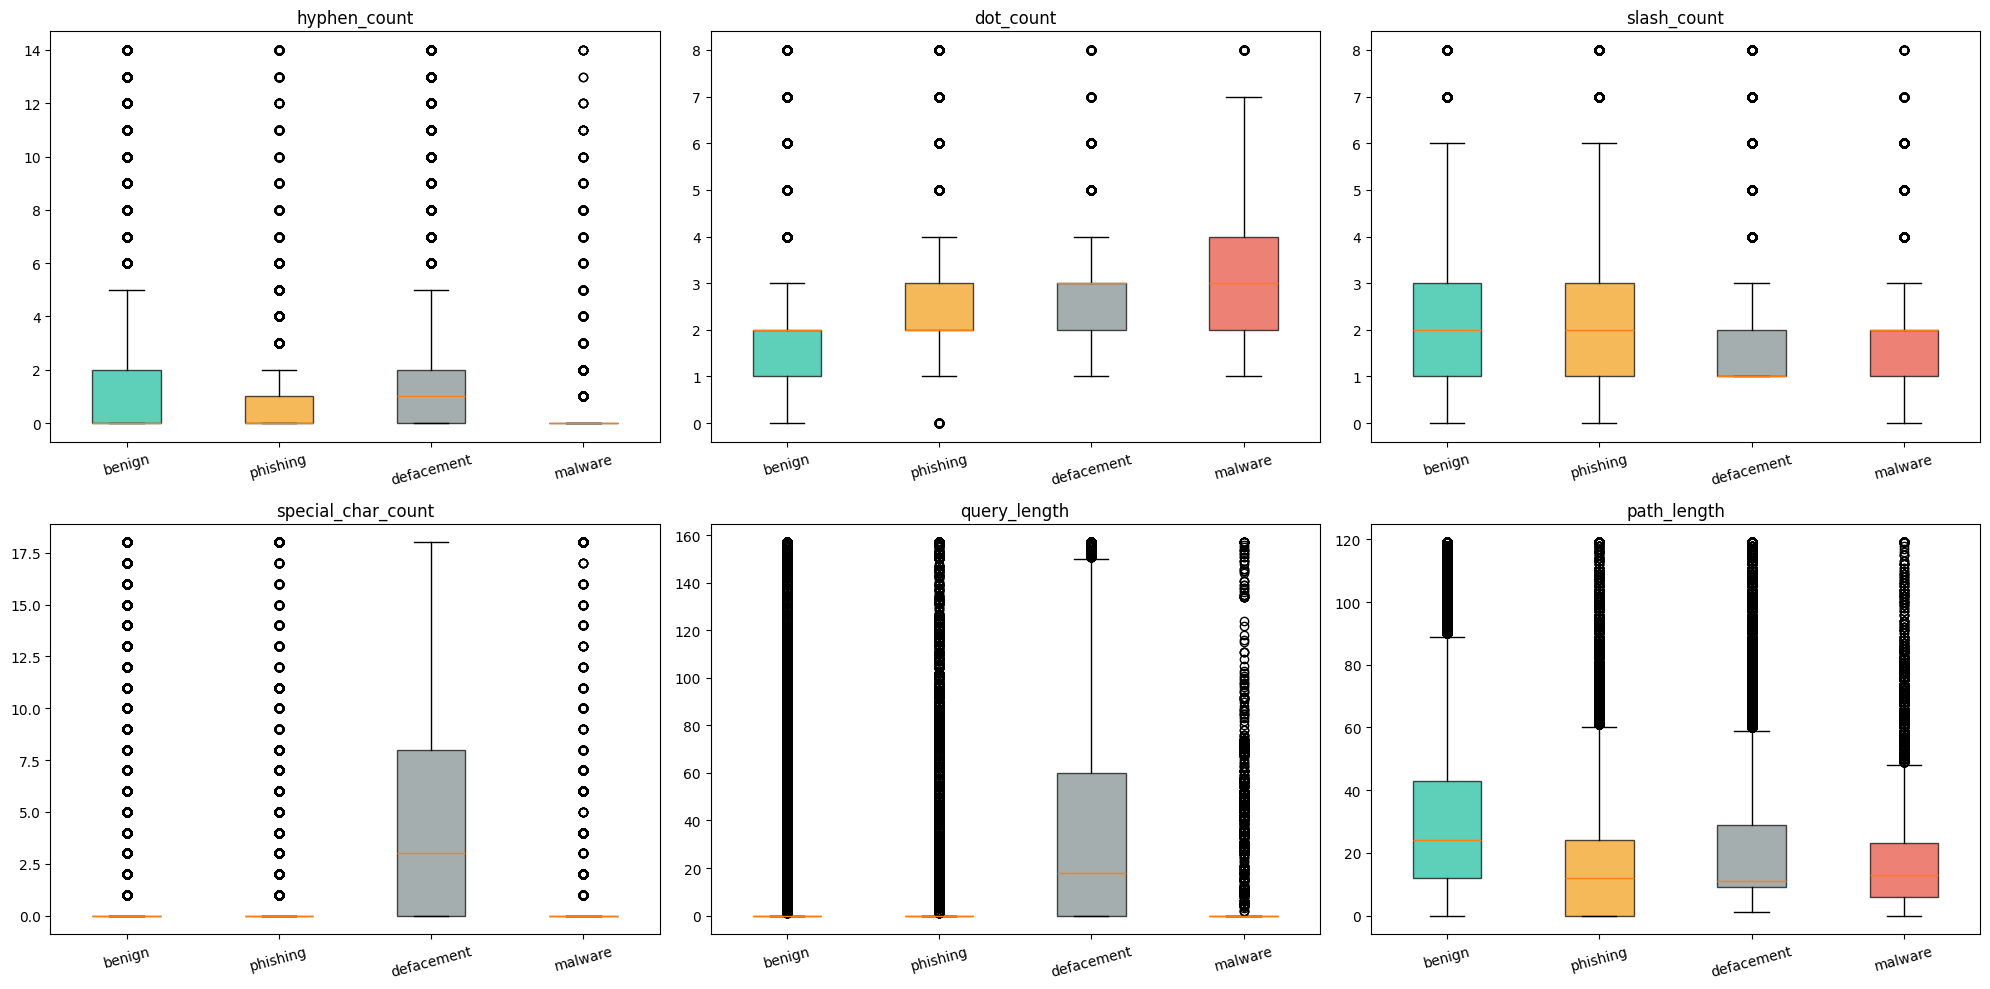

In [ ]:
# Analyzing structural components (dots, slashes, special chars) across classes.
# Phishing and Malware URLs often abuse these to create convincing fake domains or hide complex payloads
count_features = ['hyphen_count', 'dot_count', 'slash_count',
                  'special_char_count', 'query_length', 'path_length']

for col in count_features:
  df[col] = pd.to_numeric(df[col],errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, feat in zip(axes, count_features):
    cap = df[feat].quantile(0.99)
    box_data = [
        df[df['label'] == l][feat].clip(upper=cap)
        for l in label_map.values()
    ]
    bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
    for box, color in zip(bp['boxes'], bar_colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)

    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

###Feature Analysis (Boxplots)

> **`special_char_count` and `query_length` show a clear difference for Defacement:** its median values are noticeably higher than the other classes, making these features useful signals for identifying URLs with more complex query structures.

> **`dot_count` is relatively higher for Malware**, with a median around 3. This is consistent with URLs containing IP-address patterns, although the feature alone is not enough to identify malware.

> **`hyphen_count` is mostly 0 for Malware**, while Benign and Defacement show greater variation. This suggests hyphens alone are unlikely to be a strong malware indicator.

> **`path_length` is highest for Benign by median**, showing that legitimate URLs can also contain fairly long paths. So, URL length or path length alone should not be treated as a direct phishing signal.

> **`slash_count` shows considerable overlap between classes**, meaning there is no clear class separation from this feature alone.

> **Overall, the boxplots show that no single numerical feature cleanly separates all four classes.** Some features, such as `query_length`, `special_char_count`, and `dot_count`, show useful class-level differences, but the model needs to combine multiple signals to make a reliable prediction.

### Binary Feature Distribution Per Class
Percentage of URLs in each class where the binary flag = 1. `has_ip` is the strongest signal — malware uses IP addresses heavily to bypass DNS. Boxplot would just show flat lines here — percentage bars give the real insight.

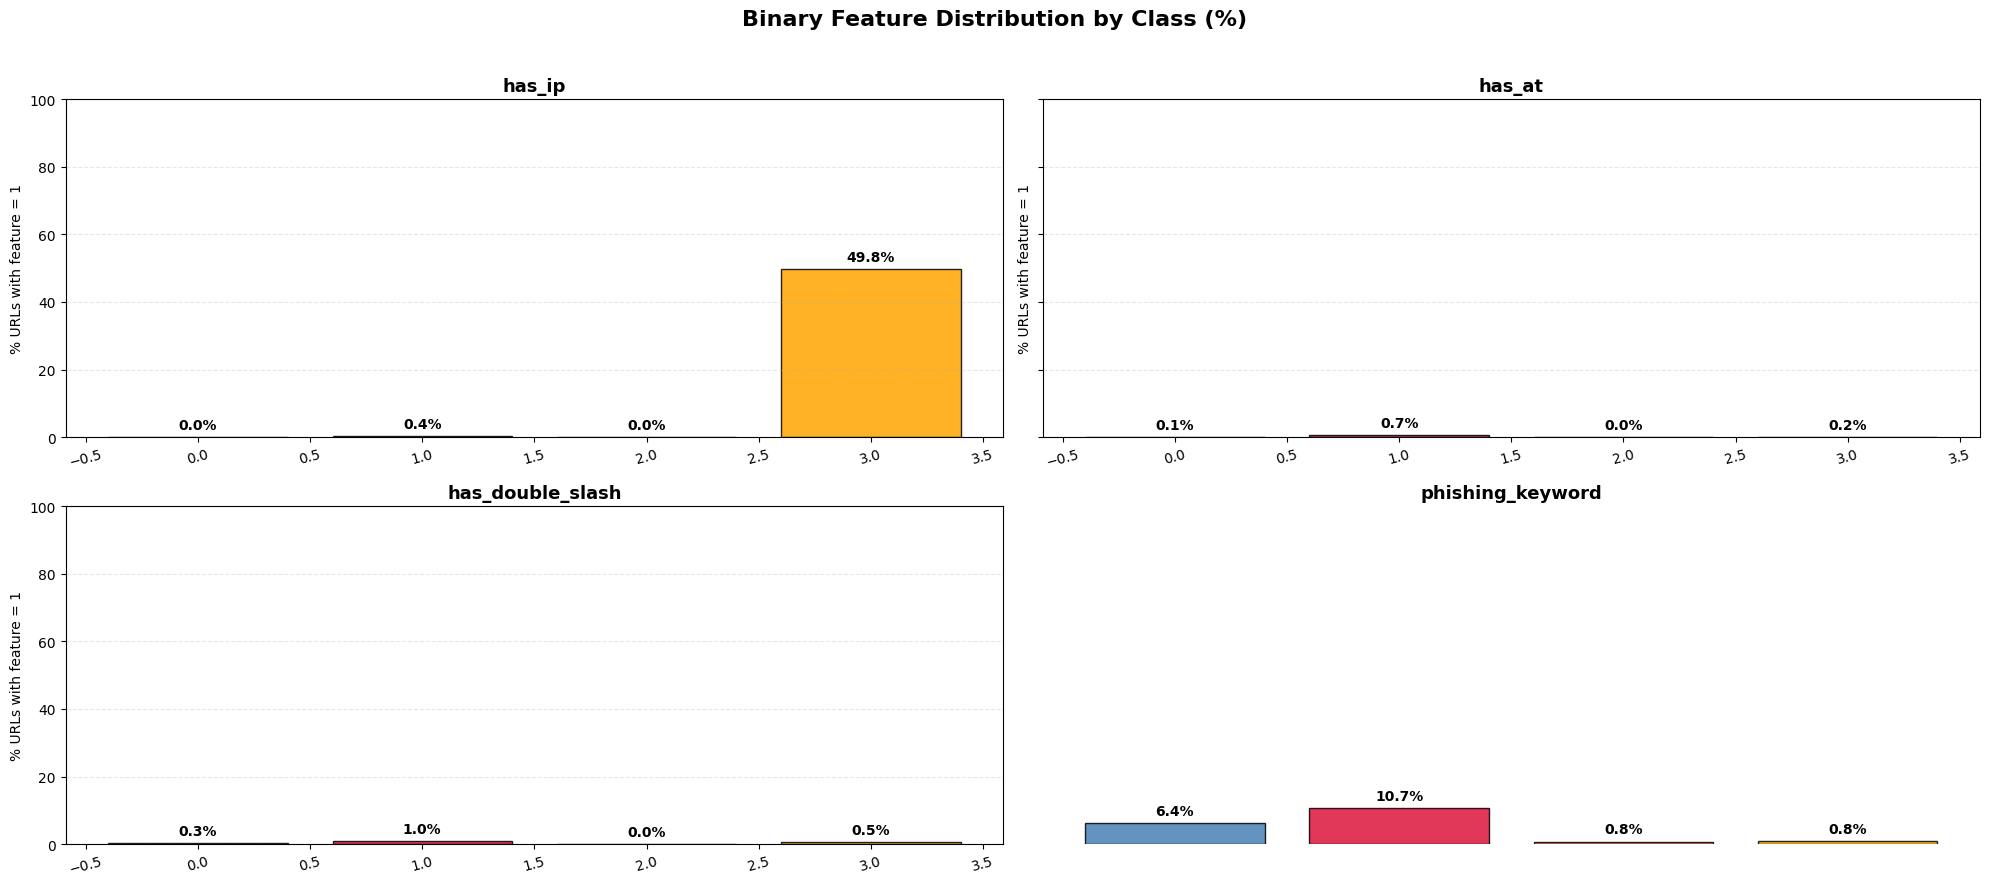

In [ ]:
# Binary features
binary_features = ['has_ip','has_at','has_double_slash',
                   'phishing_keyword',]
# Colors for each class
colors = ['steelblue', 'tomato', 'orange', 'crimson']
# Create subplots (share y-axis)
fig, axes = plt.subplots(
    2, 2,
    figsize=(20, 9),
    sharey=True
)
axes = axes.flatten()
for ax, col in zip(axes, binary_features):
    # Percentage of URLs having feature = 1
    pct = df.groupby('type')[col].mean() * 100
    pct.index = pct.index.map(label_map)
    # Bar plot
    bars = ax.bar(pct.index,
        pct.values,color=colors,edgecolor='black',alpha=0.85)
    # Title
    ax.set_title(col, fontsize=13, fontweight='bold')
    # Labels
    ax.set_ylabel('% URLs with feature = 1')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    # Percentage labels
    for bar, val in zip(bars, pct.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            min(val + 1.5, 98),
            f'{val:.1f}%',
            ha='center',va='bottom',fontsize=10,fontweight='bold')
axes[-1].axis('off')
plt.suptitle(
    'Binary Feature Distribution by Class (%)',
    fontsize=16,
    fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Binary Feature Analysis

> **`has_ip` stands out as the strongest binary signal:** it appears in **49.8% of Malware URLs**, while remaining close to 0% for the other classes. This makes IP-based URLs a useful signal for identifying malware, although it is not sufficient on its own.

> **`phishing_keyword` shows limited separation:** it appears in **10.7% of Phishing URLs** compared with **6.4% of Benign URLs**. The difference is relatively small, so keywords such as `login`, `verify`, or `secure` should not be treated as a reliable standalone phishing indicator.

> **`has_at` and `has_double_slash` are very rare across all four classes**, with both staying around or below 1%. For this dataset, these features provide limited class-level separation.

> **Overall, the binary features show that different signals behave very differently across classes.** `has_ip` provides a noticeably stronger signal for Malware, while the other binary features contribute much weaker individual separation and need to be combined with the remaining URL features.

## Machine Learning

Features ready — time to train. TLD is a string column so it gets frequency-encoded before going into the model. `stratify=y` keeps class ratios same in train and test.

In [ ]:
# use malicious_df — features were merged into it after extract_feature
X = df[feature_cols].copy()
y = df['label']

# tld_series with positional index matching malicious_df
tld_series = df['url'].apply(
    lambda u: tldextract.extract(u).suffix or 'no_tld'
).reset_index(drop=True)

print(f'X shape: {X.shape}  y shape: {y.shape}')


X shape: (641172, 12)  y shape: (641172,)


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2,random_state=42,stratify=y
)

In [ ]:
# use positional indexing to avoid index mismatch
train_pos = list(X_train.index)
test_pos  = list(X_test.index)

tld_train = tld_series.iloc[train_pos]
tld_freq  = tld_train.value_counts(normalize=True).to_dict()

X_train = X_train.fillna(0).copy()
X_test  = X_test.fillna(0).copy()

X_train['tld_encoded'] = tld_series.iloc[train_pos].map(tld_freq).fillna(0).values
X_test['tld_encoded']  = tld_series.iloc[test_pos].map(tld_freq).fillna(0).values

print(f'Train TLD NaN: {X_train["tld_encoded"].isna().sum()}')
print(f'Test  TLD NaN: {X_test["tld_encoded"].isna().sum()}')
print(f'Final X_train shape: {X_train.shape}')


Train TLD NaN: 0
Test  TLD NaN: 0
Final X_train shape: (512937, 13)


In [ ]:
X_train.isnull().sum()

,0
url_length,0
hyphen_count,0
dot_count,0
slash_count,0
special_char_count,0
has_at,0
has_double_slash,0
subdomain_count,0
query_length,0
path_length,0


### Logistic Regression
Baseline linear model. Good for understanding which features have linear relationships with the target. Phishing class (1) recall is very low — features aren't linearly separable here.

In [ ]:
log_reg = LogisticRegression(multi_class='multinomial',max_iter=1000)
param_grid = {
    'C': [0.01,0.1,1,10],
    "penalty": ['l2'],
    'solver': ['lbfgs']
}

grid_search = GridSearchCV(
    estimator=log_reg,param_grid=param_grid,cv=3,
    verbose=2,n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("\n--- GridSearch Complete ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
best_log_reg_model = grid_search.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- GridSearch Complete ---
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.7323


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lgr_model = Pipeline([
    ('scaler',StandardScaler(with_mean=False)),
    ('classifier', LogisticRegression(
        C=10,
        solver='lbfgs',
        # multi_class='multinomial',
        max_iter=1000
    ))
])
lgr_model.fit(X_train, y_train)
y_pred_log = lgr_model.predict(X_test)

accuracy_lgr = accuracy_score(y_test,y_pred_log)
print(f"Model Accuracy : {accuracy_lgr}")

print("\n---Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_log))

print('\n--Classification Report:')
print(classification_report(y_test,y_pred_log))

Model Accuracy : 0.7322103949779701

---Confusion Matrix:
[[81745  1762  2073    40]
 [16023  2155   565    78]
 [11047   356  7659     0]
 [ 2298    38    60  2336]]

--Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.95      0.83     85620
           1       0.50      0.11      0.19     18821
           2       0.74      0.40      0.52     19062
           3       0.95      0.49      0.65      4732

    accuracy                           0.73    128235
   macro avg       0.73      0.49      0.55    128235
weighted avg       0.71      0.73      0.68    128235



### Logistic Regression Results

> **Accuracy is 73.2%, but it does not tell the full story.** The model achieves **95% recall for Benign URLs**, while performance drops sharply on the attack classes. This shows that the overall accuracy is heavily influenced by its stronger performance on the majority class.

> **Phishing is the biggest weakness:** recall is only **11%**, with **16,023 out of 18,821 phishing URLs** being classified as Benign. This confirms that phishing URLs are difficult to separate using these features with a simple linear model.

> **Malware shows high precision (95%) but low recall (49%).** When the model predicts Malware, it is usually correct, but it still misses more than half of the actual Malware URLs. The confusion matrix shows **2,298 Malware URLs** being classified as Benign.

> **The macro F1-score is only 0.55**, which gives a better picture of the model's uneven performance across the four classes than accuracy alone.

> **Overall, Logistic Regression works as a useful baseline but struggles with the complex class boundaries in this dataset.** The large differences in recall across classes suggest that a more flexible non-linear model should be tested next.

### Naive Bayes (GridSearch)

> **Naive Bayes as a Probabilistic Baseline:** Naive Bayes assumes that the input features are conditionally independent given the class. Our EDA shows that some URL features have noticeable relationships, such as `url_length` and `query_length` (correlation ≈ 0.74).

> This makes Naive Bayes an interesting baseline for comparison, especially to see how well a simple probabilistic approach handles the relationships present in our URL features.

> **The actual classification results will show whether this assumption limits its performance on our four URL classes.**

In [ ]:
nb_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier',MultinomialNB())
])

param_grid = {
    'classifier__alpha':[0.01,0.1,0.5,1.0,5.0,10.0]
}

nb_grid = GridSearchCV(nb_pipeline,param_grid,cv=3,scoring='accuracy',n_jobs=-1,verbose=2)
nb_grid.fit(X_train,y_train)

print(f"Best Paramter : {nb_grid.best_params_}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Paramter : {'classifier__alpha': 0.01}


In [ ]:
naive_b_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier',MultinomialNB(alpha=0.1))
])

naive_b_model.fit(X_train,y_train)
y_pred_nb = naive_b_model.predict(X_test)

accuracy_nb = accuracy_score(y_test,y_pred_nb)

print('\n---Confusion Matrix')
print(confusion_matrix(y_test,y_pred_nb))

print('\n--Classification Report')
print(classification_report(y_test,y_pred_nb))


---Confusion Matrix
[[77063  4393  4129    35]
 [15172  3204   365    80]
 [ 9124   672  9266     0]
 [ 2018    86   292  2336]]

--Classification Report
              precision    recall  f1-score   support

           0       0.75      0.90      0.82     85620
           1       0.38      0.17      0.24     18821
           2       0.66      0.49      0.56     19062
           3       0.95      0.49      0.65      4732

    accuracy                           0.72    128235
   macro avg       0.69      0.51      0.57    128235
weighted avg       0.69      0.72      0.69    128235



### Naive Bayes Results

> **Accuracy is 72%, slightly below the Logistic Regression baseline (73%).** More importantly, the model still shows uneven performance across the four classes, with much weaker recall for Phishing and Malware than for Benign URLs.

> **Phishing remains the main weakness:** recall is only **17%**, with **15,172 out of 18,821 phishing URLs** classified as Benign. This shows that the probabilistic baseline still struggles to distinguish phishing URLs from legitimate ones.

> **Malware recall is 49%**, the same as the Logistic Regression baseline. Although its precision is high at **95%**, the model still misses more than half of the actual Malware URLs.

> **The macro F1-score is 0.57**, only slightly higher than Logistic Regression's 0.55. This indicates that the improvement is limited, especially across the minority classes.

> **Overall, Naive Bayes provides a useful probabilistic baseline, but it does not solve the class-separation problem.** The results justify testing more flexible non-linear models such as Random Forest and XGBoost next.

### XGBoost — RandomizedSearch
RandomizedSearch first to narrow down the parameter space — faster than full GridSearch on 640k rows. Then GridSearch refines the best region found here.

In [ ]:
param_dist = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [3, 6, 9],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        tree_method='hist',
        device='cuda',
        random_state=42
    ))
])
xgb_random = RandomizedSearchCV(
    xgb_pipeline,param_distributions=param_dist,
    n_iter = 5,cv=3,scoring='accuracy',verbose=2,n_jobs=-1,
    random_state=42
)
xgb_random.fit(X_train,y_train)
print(f'Best Parameters:{xgb_random.best_params_}')

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:01:58] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:01:58] WARNING: /__w/xgboost/xgboost/src/context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters:{'classifier__n_estimators': 50, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.2}


In [ ]:
print("XGBoost Using Randomized Search")
y_pred_xgb = xgb_random.predict(X_test)
print(f'\n--Accuracy:{accuracy_score(y_test,y_pred_xgb)}')

print('\n---Confusion Matrix')
print(confusion_matrix(y_test,y_pred_xgb))

print('\n --Classification Report')
print(classification_report(y_test,y_pred_xgb))


XGBoost Using Randomized Search

--Accuracy:0.8689827270246032

---Confusion Matrix
[[82141  2321  1101    57]
 [ 6590 11554   655    22]
 [ 4111   726 14223     2]
 [  955   202    59  3516]]

 --Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     85620
           1       0.78      0.61      0.69     18821
           2       0.89      0.75      0.81     19062
           3       0.98      0.74      0.84      4732

    accuracy                           0.87    128235
   macro avg       0.88      0.77      0.81    128235
weighted avg       0.87      0.87      0.86    128235



### XGBoost (Randomized Search)

> **The performance improved substantially over both baseline models:** accuracy reached **86.9%** and macro F1 increased to **0.81**, compared with 0.55 for Logistic Regression and 0.57 for Naive Bayes. The improvement is also visible across the individual attack classes, not just in overall accuracy.

> **Phishing detection improved significantly:** recall increased to **61%**, compared with only 11% for Logistic Regression and 17% for Naive Bayes. The model still missed **7,267 phishing URLs**, so Phishing remains the most challenging class.

> **Malware detection reached 74% recall with 98% precision.** This means the model catches a much larger portion of Malware URLs while keeping false Malware predictions relatively low.

> **Defacement also improved to 75% recall and 81% F1-score**, showing that the model is handling this class much better than the baseline approaches.

> **Overall, XGBoost clearly outperforms both baseline models across the main evaluation metrics.** The results strongly support using a non-linear model for this URL classification problem, where different URL characteristics overlap across classes.

## XGBoost (GridSearch)

> RandomizedSearch gave us a strong XGBoost configuration, so the next step is to search more carefully around that parameter range using GridSearch. This helps us check whether further tuning can improve the model before the final comparison with Random Forest.

In [ ]:
# Grid search
param_grid_xgb = {
    'classifier__n_estimators': [40,50,70],
    'classifier__max_depth':[5,6,7],
    'classifier__learning_rate':[0.15,0.2,0.25]
}
xgb_grid = GridSearchCV(
    xgb_pipeline,param_grid=param_grid_xgb,
    cv=3,scoring='accuracy',
    verbose=2,
    n_jobs=-1
)
xgb_grid.fit(X_train,y_train)
print(f'Final Best Parameter:{xgb_grid.best_params_}')

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:10] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:15:10] WARNING: /__w/xgboost/xgboost/src/context.cc:218: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Final Best Parameter:{'classifier__learning_rate': 0.25, 'classifier__max_depth': 7, 'classifier__n_estimators': 70}


In [ ]:
print("XGBoost Using Grid SearchCV")

grid_xgb_model = xgb_grid.best_estimator_

y_pred_xgb = grid_xgb_model.predict(X_test)

print(f'Accuracy:{accuracy_score(y_test,y_pred_xgb)}')

print('\n Confusion Matrix:')
print(confusion_matrix(y_test,y_pred_xgb))

print('\nClassification Report:')
print(classification_report(y_test,y_pred_xgb))


XGBoost Using Grid SearchCV
Accuracy:0.8863102897024994

 Confusion Matrix:
[[82408  2253   887    72]
 [ 5753 12425   618    25]
 [ 3434   667 14958     3]
 [  616   204    47  3865]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     85620
           1       0.80      0.66      0.72     18821
           2       0.91      0.78      0.84     19062
           3       0.97      0.82      0.89      4732

    accuracy                           0.89    128235
   macro avg       0.89      0.81      0.84    128235
weighted avg       0.88      0.89      0.88    128235



### XGBoost (GridSearch) Results

> **GridSearch gave a further improvement over the RandomizedSearch model.** Accuracy increased from **86.90% to 88.63%**, while Macro F1 improved from **0.81 to 0.84**, showing better overall performance across all four classes.

> **Malware detection showed the biggest improvement:** recall increased from **74% to 82%**, while precision remained very high at **97%**. This means the tuned model is catching more Malware URLs without a large increase in false Malware predictions.

> **Phishing recall improved from 61% to 66%.** It is still the most challenging class, but the improvement shows that the additional hyperparameter tuning helped the model separate more phishing URLs from benign traffic.

> **Defacement recall also improved from 75% to 78%**, with its F1-score reaching **0.84**.

> **Overall, GridSearch produced our strongest XGBoost configuration so far.** The consistent improvement in macro F1 and recall across the attack classes suggests that focused hyperparameter tuning helped the model handle the URL classification problem more effectively.

### Random Forest (GridSearch)

> **The final model is a tuned Random Forest ensemble.** Since the dataset is imbalanced, with Benign URLs making up around 67% of the data, `class_weight='balanced'` is used to give more importance to the minority classes during training.

> The main goal is to see whether Random Forest can improve detection of the minority attack classes, particularly Phishing and Malware, compared with our tuned XGBoost model.

> **The final comparison will be based on more than accuracy**, with particular attention to macro F1-score and recall for the individual attack classes.

In [ ]:
print('Random Forest with Grid Search')
rf_pipeline = Pipeline([
    ('scaler',StandardScaler(with_mean=False)),
    ('classifier',RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])
param_grid = {
    'classifier__n_estimators':[50,100],
    'classifier__max_depth':[15,20],
    'classifier__min_samples_split':[5,10]}
rf_grid = GridSearchCV(rf_pipeline,
                       param_grid,cv=3,scoring='accuracy',
                       n_jobs=-1,
                       verbose=2)

rf_grid.fit(X_train,y_train)
print(f"Best Parameter:{rf_grid.best_params_}")

rf_pipeline.fit(X_train,y_train)
y_pred_rf = rf_grid.predict(X_test)

print(f'\nAccuracy:{accuracy_score(y_test,y_pred_rf)}')


print('\n Confusion Matrix:')
print(confusion_matrix(y_test,y_pred_rf))

print('\n Ctlassifcation Report:')
print(classification_report(y_test,y_pred_rf))

Random Forest with Grid Search
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameter:{'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Accuracy:0.8768978827933092

 Confusion Matrix:
[[75988  6624  2344   664]
 [ 2428 15461   763   169]
 [ 1438   844 16747    33]
 [  203   233    43  4253]]

 Ctlassifcation Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     85620
           1       0.67      0.82      0.74     18821
           2       0.84      0.88      0.86     19062
           3       0.83      0.90      0.86      4732

    accuracy                           0.88    128235
   macro avg       0.82      0.87      0.84    128235
weighted avg       0.89      0.88      0.88    128235



### Random Forest Results

> **Random Forest achieved 87.69% accuracy with a macro F1-score of 0.84.** Although its accuracy is slightly lower than tuned XGBoost (88.63%), its recall across the attack classes is noticeably stronger.

> **Phishing recall reached 82%, compared with 66% for XGBoost.** This is a significant improvement for the class that remained the hardest to detect throughout the earlier models.

> **Malware recall reached 90% and Defacement recall reached 88%.** These are the highest recall values we've seen so far for these two attack classes, showing that Random Forest is detecting a larger portion of the actual malicious URLs.

> **There is a clear precision-recall trade-off.** Phishing precision is 67%, meaning the model catches more phishing URLs but also incorrectly flags some Benign URLs as Phishing. This trade-off is visible in the confusion matrix, where **6,624 Benign URLs** were classified as Phishing.

> **Macro F1 is 0.84, matching the tuned XGBoost model (0.84).** The key difference is that Random Forest achieves substantially higher recall on the attack classes, while XGBoost maintains better overall accuracy and precision.

> **For this project's threat-detection objective, Random Forest becomes a strong candidate for the final model.** The final choice should consider the trade-off between catching more threats and generating false positives rather than relying on accuracy alone.

## Model Comparison

> The two strongest models were evaluated on the same test set. XGBoost achieved slightly higher accuracy (**88.63% vs 87.69%**), while both models achieved the same Macro F1-score (**0.84**).

> Random Forest, however, achieved substantially higher recall across the attack classes: **82% for Phishing, 90% for Malware, and 88% for Defacement**, compared with 66%, 82%, and 78% for XGBoost.

> Since this project focuses on detecting malicious URLs, catching actual threats is more important than maximizing overall accuracy alone. Based on this priority, **Random Forest was selected as the final deployment model.**

In [ ]:
print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['benign','phishing','defacement','malware']))

print("=== XGBOOST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb,
      target_names=['benign','phishing','defacement','malware']))

=== RANDOM FOREST ===
Accuracy: 0.8769
              precision    recall  f1-score   support

      benign       0.95      0.89      0.92     85620
    phishing       0.67      0.82      0.74     18821
  defacement       0.84      0.88      0.86     19062
     malware       0.83      0.90      0.86      4732

    accuracy                           0.88    128235
   macro avg       0.82      0.87      0.84    128235
weighted avg       0.89      0.88      0.88    128235

=== XGBOOST ===
Accuracy: 0.8863
              precision    recall  f1-score   support

      benign       0.89      0.96      0.93     85620
    phishing       0.80      0.66      0.72     18821
  defacement       0.91      0.78      0.84     19062
     malware       0.97      0.82      0.89      4732

    accuracy                           0.89    128235
   macro avg       0.89      0.81      0.84    128235
weighted avg       0.88      0.89      0.88    128235



## Save Final Model

In [ ]:
joblib.dump(rf_grid.best_estimator_, 'url_model.pkl')
print('Saved: url_model.pkl')

joblib.dump(tld_freq, 'tld_freq.pkl')
print('Saved: tld_freq.pkl')

MODEL_COLS = list(rf_grid.best_estimator_.named_steps['scaler'].feature_names_in_)
joblib.dump(MODEL_COLS, 'model_cols.pkl')
print(f'Saved: model_cols.pkl → {MODEL_COLS}')

from google.colab import files
files.download('/content/url_model.pkl')


Saved: url_model.pkl
Saved: tld_freq.pkl
Saved: model_cols.pkl → ['url_length', 'hyphen_count', 'dot_count', 'slash_count', 'special_char_count', 'has_at', 'has_double_slash', 'subdomain_count', 'query_length', 'path_length', 'phishing_keyword', 'has_ip', 'tld_encoded']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Live Inference & Real-World Testing

> During initial testing, the model did not generalize well to unseen real-world URLs. In particular, several legitimate websites were incorrectly classified as phishing, while some suspicious URLs also produced unreliable predictions. This exposed a gap between the patterns present in the original dataset and the URLs the model would encounter outside the dataset.

> To address this, we added a small set of manually collected realistic URL examples, with particular focus on underrepresented benign URLs. The additional examples were merged with the original dataset, duplicate URLs were removed, URL formats were normalized, and the model was retrained using the same feature-extraction pipeline.

> After retraining, we tested the model again on previously unseen URLs from different websites. The model showed noticeably more consistent behavior on legitimate URLs and suspicious URL patterns compared with the earlier version.

> This testing was important because it helped us identify a dataset/generalization issue that was not obvious from the original test-set metrics alone. The manual examples were not added to artificially improve the reported test score; they were introduced to make the training data more representative of the types of URLs encountered during real-world testing.